<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_5_Ensemble/18_5_3_Boosting_and_BART.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Boosting and BART: Sequential Learning

**Author:** Brad Sheese

---

## Introduction: Learning from Mistakes

In the previous notebook, we saw how bagging and random forests reduce **variance** by averaging many independent trees. Boosting takes a different approach: it reduces **bias** by building trees sequentially, where each new tree corrects the errors of the ensemble so far.

Recall from 18_1_5: Random Forests train trees in parallel (independent), while Boosting trains trees sequentially (each one learns from the previous). This makes boosting more powerful but also more prone to overfitting if not carefully controlled.

### Learning Objectives
By the end of this notebook, you will be able to:
1. Implement AdaBoost and Gradient Boosting classifiers.
2. Understand the difference between adaptive boosting (reweighting) and gradient boosting (residuals).
3. Tune boosting hyperparameters using GridSearchCV.
4. Compare boosting to bagging and random forests using classification metrics.
5. Understand the concept of BART (Bayesian Additive Regression Trees) and its uncertainty quantification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import (
    AdaBoostClassifier, GradientBoostingClassifier,
    RandomForestClassifier, BaggingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc
)

sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

# Flip target: 1=malignant, 0=benign (matching original UCI encoding)
y = 1 - y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Class distribution after flip: {y_test.mean():.1%} malignant (1), {(1-y_test.mean()):.1%} benign (0)")

Class distribution after flip: 37.4% malignant (1), 62.6% benign (0)


---
## 1. AdaBoost: Adaptive Boosting

AdaBoost is the original boosting algorithm. It works by:

1. Starting with equal weights for all training samples.
2. Training a weak learner (typically a shallow tree, or "stump").
3. Increasing the weights of misclassified samples so the next tree focuses on them.
4. Repeating for a fixed number of trees.
5. Combining all trees with weighted voting (better trees get more weight).

Think of it as a tutor who gives extra attention to the problems the student keeps getting wrong.

### Why Stumps (max_depth=1)?

AdaBoost uses decision stumps — trees with a single split — as base learners. This might seem too simple to be useful. But that's exactly the point: stumps are *weak learners* that are only slightly better than random guessing. AdaBoost's power comes from combining hundreds of these weak learners, each focusing on different hard-to-classify samples. If we used deep trees instead, each one would already be quite strong, and there would be little room for the sequential correction process to add value. Deep trees in boosting also overfit much faster.

This contrasts with bagging (18_5_2), where we used *deep* trees. Bagging averages many overfitting trees to cancel their individual errors. Boosting builds weak trees sequentially, each one correcting the previous ensemble's mistakes. Different strategies for different goals: bagging reduces variance, boosting reduces bias.

In [3]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
y_proba_ada = ada.predict_proba(X_test)[:, 1]

print(f"AdaBoost Accuracy:          {accuracy_score(y_test, y_pred_ada):.3f}")
print(f"AdaBoost F1 Score:          {f1_score(y_test, y_pred_ada):.3f}")
print(f"AdaBoost Malignant Recall:  {recall_score(y_test, y_pred_ada):.3f}")

AdaBoost Accuracy:          0.977
AdaBoost F1 Score:          0.968
AdaBoost Malignant Recall:  0.938


---
## 2. Gradient Boosting: Predicting the Residuals

Gradient Boosting is more sophisticated than AdaBoost. Instead of reweighting samples, it:

1. Starts with a simple prediction (the log-odds of the positive class).
2. Calculates the residuals (errors) of the current ensemble.
3. Trains a new tree to predict these residuals.
4. Adds the tree's predictions to the ensemble, scaled by the learning rate.
5. Repeats for a fixed number of trees.

Think of it as a sculptor refining a block of marble — each tree chips away at the remaining error. This is the same concept we saw in 18_1_5 with the Ames Housing data.

### Key Hyperparameters
- **n_estimators**: Number of trees. More trees = more capacity but risk of overfitting.
- **learning_rate**: Shrinkage factor. Smaller values = slower learning, need more trees, but often better generalization.
- **max_depth**: Tree complexity. Boosting typically uses shallow trees (depth 3-5).

In [4]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print(f"Gradient Boosting Accuracy:         {accuracy_score(y_test, y_pred_gb):.3f}")
print(f"Gradient Boosting F1 Score:         {f1_score(y_test, y_pred_gb):.3f}")
print(f"Gradient Boosting Malignant Recall: {recall_score(y_test, y_pred_gb):.3f}")

Gradient Boosting Accuracy:         0.965
Gradient Boosting F1 Score:         0.952
Gradient Boosting Malignant Recall: 0.922


---
## 3. Classification Metrics: Full Evaluation

Let's evaluate the Gradient Boosting model using the full metric suite.

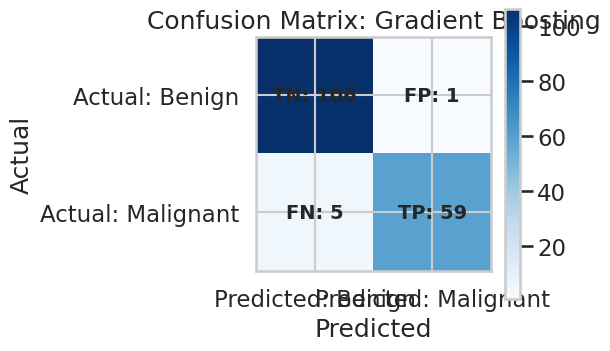


--- Medical Interpretation ---
False Negatives (missed cancers): 5
False Positives (unnecessary biopsies): 1

--- Classification Report ---
               precision    recall  f1-score   support

   Benign (0)       0.95      0.99      0.97       107
Malignant (1)       0.98      0.92      0.95        64

     accuracy                           0.96       171
    macro avg       0.97      0.96      0.96       171
 weighted avg       0.97      0.96      0.96       171



In [5]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Benign', 'Predicted: Malignant'])
ax.set_yticklabels(['Actual: Benign', 'Actual: Malignant'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix: Gradient Boosting')

labels = [[f'TN: {tn}', f'FP: {fp}'], [f'FN: {fn}', f'TP: {tp}']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print(f"\n--- Medical Interpretation ---")
print(f"False Negatives (missed cancers): {fn}")
print(f"False Positives (unnecessary biopsies): {fp}")
print(f"\n--- Classification Report ---")
print(classification_report(y_test, y_pred_gb, target_names=['Benign (0)', 'Malignant (1)']))

### ROC Curve

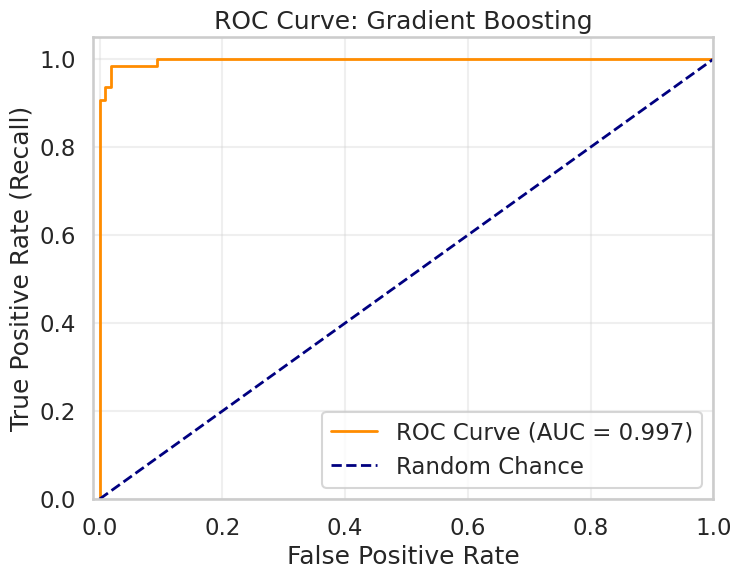

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_proba_gb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Gradient Boosting')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

---
## 4. Hyperparameter Tuning with GridSearchCV

Boosting is more sensitive to hyperparameters than random forests. Let's tune the key parameters.

**Runtime note:** This cell tests 27 hyperparameter combinations across 5 folds (135 model fits). It may take 30-60 seconds.

In [7]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

best_gb = grid_search.best_estimator_
tuned_acc = accuracy_score(y_test, best_gb.predict(X_test))
tuned_recall = recall_score(y_test, best_gb.predict(X_test))
print(f"\nTuned GB Test Accuracy:         {tuned_acc:.3f}")
print(f"Tuned GB Malignant Recall:      {tuned_recall:.3f}")

# Compare with default
default_acc = accuracy_score(y_test, gb.predict(X_test))
default_recall = recall_score(y_test, gb.predict(X_test))
print(f"\nDefault GB (200 trees) Accuracy:  {default_acc:.3f}")
print(f"Default GB (200 trees) Recall:    {default_recall:.3f}")
print(f"\nNote: The tuned model uses {grid_search.best_params_['n_estimators']} trees with learning_rate={grid_search.best_params_['learning_rate']}.")
print(f"The shrinkage trade-off: smaller learning rates need more trees but often generalize better.")

Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300}
Best CV F1 Score: 0.9514

Tuned GB Test Accuracy:         0.971
Tuned GB Malignant Recall:      0.922

Default GB (200 trees) Accuracy:  0.965
Default GB (200 trees) Recall:    0.922

Note: The tuned model uses 300 trees with learning_rate=0.05.
The shrinkage trade-off: smaller learning rates need more trees but often generalize better.


---
## 5. Comparing All Methods

Let's compare AdaBoost, Gradient Boosting, Random Forest, and a single tree using 10-fold cross-validation. This time we include **malignant recall** — the most clinically relevant metric.

In [8]:
models = {
    "Single Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)

print(f"{'Model':<25} | {'Mean Acc':<10} | {'Std Dev':<10} | {'Mean F1':<10} | {'Mean Recall':<12} | {'Mean AUC':<10}")
print("-" * 90)

for name, model in models.items():
    acc_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    f1_scores = cross_val_score(model, X, y, cv=kf, scoring='f1')
    recall_scores = cross_val_score(model, X, y, cv=kf, scoring='recall')
    roc_scores = cross_val_score(model, X, y, cv=kf, scoring='roc_auc')
    print(f"{name:<25} | {acc_scores.mean():.4f}     | {acc_scores.std():.4f}     | {f1_scores.mean():.4f}     | {recall_scores.mean():.4f}      | {roc_scores.mean():.4f}")

Model                     | Mean Acc   | Std Dev    | Mean F1    | Mean Recall  | Mean AUC  
------------------------------------------------------------------------------------------


Single Tree               | 0.9350     | 0.0359     | 0.9087     | 0.9095      | 0.9279


Random Forest             | 0.9648     | 0.0111     | 0.9521     | 0.9416      | 0.9926


AdaBoost                  | 0.9701     | 0.0158     | 0.9589     | 0.9417      | 0.9940


Gradient Boosting         | 0.9665     | 0.0216     | 0.9546     | 0.9459      | 0.9911


### Interpreting the Results

- **Gradient Boosting** typically achieves the highest accuracy and F1 — it's the most powerful of the methods we've tested.
- **Random Forest** is close behind and often more stable (lower standard deviation).
- **AdaBoost** can be competitive but is more sensitive to noisy data and outliers.
- **Single Tree** has the highest variance — its performance depends heavily on which samples end up in each fold.

The **malignant recall** column is the most clinically relevant: it tells us what fraction of actual cancers each model catches on average. The AUC scores confirm that Gradient Boosting and Random Forest both achieve excellent discrimination between malignant and benign tumors.

### Note on BART

BART (Bayesian Additive Regression Trees) is not included in this comparison because it requires specialized libraries (`pymc`, `bartpy`) that are not part of scikit-learn. Conceptually, BART would fit between Random Forest and Gradient Boosting in terms of accuracy, but with the unique advantage of providing credible intervals for each prediction.

---
## 6. Probability Calibration

In a medical context, the actual probability values matter — not just the predicted class. If a model says "95% probability of malignancy," a doctor needs to trust that number.

**Calibration** checks whether the predicted probabilities match reality. A well-calibrated model that predicts 80% malignancy should be correct about 80% of the time.

Random Forests tend to produce well-calibrated probabilities. Gradient Boosting, however, often produces probabilities that are too extreme (too close to 0 or 1). Let's check.

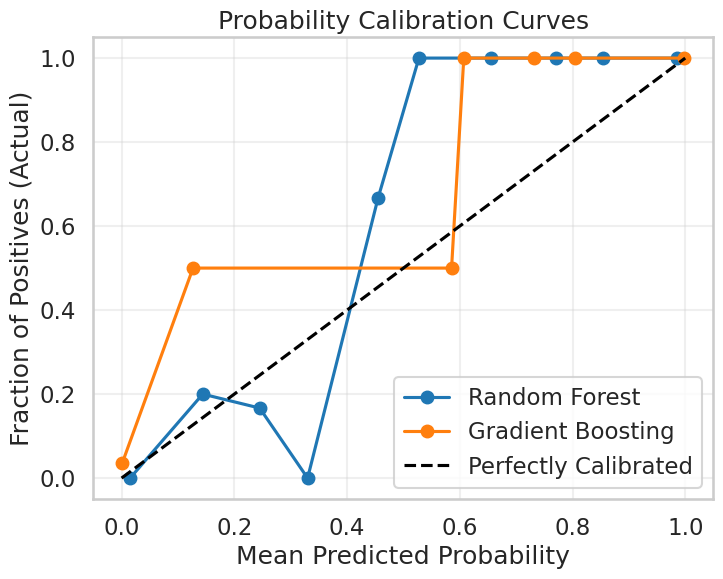

If a model's curve follows the diagonal, its probabilities are well-calibrated.
Curves above the diagonal mean the model underestimates probabilities.
Curves below the diagonal mean the model overestimates probabilities.


In [9]:
from sklearn.calibration import calibration_curve

# Train fresh models for calibration comparison
rf_cal = RandomForestClassifier(n_estimators=200, random_state=42)
rf_cal.fit(X_train, y_train)
y_proba_rf_cal = rf_cal.predict_proba(X_test)[:, 1]

gb_cal = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb_cal.fit(X_train, y_train)
y_proba_gb_cal = gb_cal.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))

for name, y_proba in [("Random Forest", y_proba_rf_cal), ("Gradient Boosting", y_proba_gb_cal)]:
    frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
    ax.plot(mean_pred, frac_pos, 'o-', label=name)

ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Actual)')
ax.set_title('Probability Calibration Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("If a model's curve follows the diagonal, its probabilities are well-calibrated.")
print("Curves above the diagonal mean the model underestimates probabilities.")
print("Curves below the diagonal mean the model overestimates probabilities.")

### Your Turn

1. The tuned Gradient Boosting model found specific values for `learning_rate` and `n_estimators`. How does this relate to the shrinkage concept? Would a smaller learning rate with more trees likely perform better or worse?
2. Compare the false negative counts: how many cancers did the single tree miss vs. the gradient boosting model? In a clinical setting, is this difference meaningful?
3. If BART were available and gave a 95% credible interval of [60%, 95%] for a particular patient's malignancy probability, how would a doctor's decision differ from a model that just says "malignant"?

## Conclusion

Boosting takes a fundamentally different approach from bagging:

1. **AdaBoost** reweights misclassified samples, forcing subsequent trees to focus on hard cases.
2. **Gradient Boosting** predicts residuals, sequentially chipping away at the remaining error.
3. **Hyperparameter tuning is critical** — boosting is more sensitive to settings than random forests.
4. **BART** adds Bayesian uncertainty quantification, providing credible intervals alongside predictions.

In the final notebook of this series, we'll bring all five methods together in a head-to-head comparison using nested cross-validation for unbiased performance estimates.